# Homework 1: Aircraft inventory analysis

In this homework, we will explore the aircraft inventory dataset from 2006 to 2023 (Source: Bureau of Transportation Statistics, www.bts.gov).  

**Some useful resources:**
- You may find explanation of the dataset attributes available in [BTS dataset attribute summary](https://www.transtats.bts.gov/Fields.asp?gnoyr_VQ=GEH).
- You may verify some of your analyses by comparing your results with the BTS analysis dashboard.  The dashboard is reachable via the "Analysis" column in the attribute summary linked above.

**General rules of thumb for homeworks:**
- Read the homework questions carefully.
- Explain your choices.
- Present your findings concisely.
- Use tables, plots, and summary statistics to aid your presentation of findings.
- If you have an idea in mind but could not implement (in code), present the idea thoroughly and how you would have implemented the code. 

### Tasks:

For all tasks below, create one or more functions for any systematic changes to the dataset.  For instance, someone could run the sequence of functions to transform the dataset.

Specify the sequence of functions.

1. Investigate the missing data in this dataset. Specifically, for each of the following variables that have missing data, decide if any imputation is possible.  Give your reasoning and code for how you decide to impute missing values.  
    - Columns for investigation: `CARRIER`, `CARRIER_NAME`, `MANUFACTURE_YEAR`, `NUMBER_OF_SEATS`, `CAPACITY_IN_POUNDS`, and `AIRLINE_ID`.
    - For example, watch out for "North American Airlines" aircrafts.  Are the `CARRIER`/`UNIQUE_CARRIER` column *really* missing?

2. Inspect the columns `MANUFACTURER`, `MODEL`, `AIRCRAFT_STATUS`, and `OPERATING_STATUS`.  Decide, for each column, if transformation or standardization of data are required.  Give your reasoning and code if you decide to transform the data.  

    **Hints:**
    - For very messy data like manufacturer/model names, give your best attempt. It is okay to not catch them all.
    - Use `value_counts()` to identify "big wins".
    - Break down into multiple steps, instead of having one line of code to do them all.

3. Remove data rows that still have missing values.  Report the amount of remaining data you obtained.

4. Transformation and derivative variables
   - For the columns `NUMBER_OF_SEATS` and `CAPACITY_IN_POUNDS`, check the skewness in the variable and plot a histogram for each variable.
   - The Box-Cox transformation (`scipy.stats.boxcox`) is one possible way to transform variables into a "more-normal-like" variable.  Apply the Box-Cox transformation for these two columns and save them as new columns, i.e. `XXXXXXXXX_BOXCOX`.
   - Plot a histogram for each transformed variable.
   - Describe what you observe before and after transformation.

5. Feature engineering
    - Create a new column `SIZE` by the quartiles of `NUMBER_OF_SEATS`
        - below 25% percentile: `SMALL`
        - 25% - 50% percentile: `MEDIUM`
        - 50% - 75% percentile: `LARGE`
        - above 75% percentile: `XLARGE`
    - For each size group, provide and plot the proportions of aircrafts that are operating versus not (`OPERATING_STATUS`). 
    - For each size group, provide and plot the proportions of aircrafts belonging to each aircraft status group (`AIRCRAFT_STATUS`).
    - Provide a written summary of your findings.

### Dataset
You may read in the dataset with the following code.  Otherwise, you can find the [dataset](https://github.com/mosesyhc/de300-2026wi/raw/refs/heads/main/datasets/T_F41SCHEDULE_B43.zip) available in the `dataset` directory.  *Note* that `pandas.read_csv()` is capable of reading a zipped .csv file and no unzipping is required.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
inventory = pd.read_csv('T_F41SCHEDULE_B43.zip')

C:\Users\Natha\AppData\Local\Temp\ipykernel_46432\1804355328.py:3: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  inventory = pd.read_csv('T_F41SCHEDULE_B43.zip')


# Task 1

In [3]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132313 entries, 0 to 132312
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 132313 non-null  int64  
 1   CARRIER              132264 non-null  object 
 2   CARRIER_NAME         132208 non-null  object 
 3   MANUFACTURE_YEAR     132310 non-null  float64
 4   UNIQUE_CARRIER_NAME  132208 non-null  object 
 5   SERIAL_NUMBER        132313 non-null  object 
 6   TAIL_NUMBER          132313 non-null  object 
 7   AIRCRAFT_STATUS      132313 non-null  object 
 8   OPERATING_STATUS     132313 non-null  object 
 9   NUMBER_OF_SEATS      132306 non-null  float64
 10  MANUFACTURER         132313 non-null  object 
 11  AIRCRAFT_TYPE        102380 non-null  object 
 12  MODEL                132302 non-null  object 
 13  CAPACITY_IN_POUNDS   132212 non-null  float64
 14  ACQUISITION_DATE     131346 non-null  object 
 15  AIRLINE_ID       

In [4]:
categories = ['CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR', 'NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS', 'AIRLINE_ID']
inventory[categories].head()

,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,NUMBER_OF_SEATS,CAPACITY_IN_POUNDS,AIRLINE_ID
0,16,PSA Airlines Inc.,2003.0,50.0,47000.0,20397.0
1,16,PSA Airlines Inc.,2003.0,50.0,47000.0,20397.0
2,16,PSA Airlines Inc.,2003.0,50.0,47000.0,20397.0
3,16,PSA Airlines Inc.,2003.0,50.0,47000.0,20397.0
4,16,PSA Airlines Inc.,2003.0,50.0,47000.0,20397.0


In [5]:
inventory.head()

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16


In [6]:
def cast_to_int(df):
    cols = ['MANUFACTURE_YEAR', 'NUMBER_OF_SEATS', 'AIRLINE_ID']
    df_copy = df.copy()
    df_copy[cols] = df_copy[cols].astype('Int64')
    return df_copy

In [7]:
inventory_int = cast_to_int(inventory)

In [8]:
inventory_int.describe()

,YEAR,MANUFACTURE_YEAR,NUMBER_OF_SEATS,CAPACITY_IN_POUNDS,AIRLINE_ID
count,132313.000000,132310.0,132306.0,132212.000000,132208.0
mean,2014.657706,2000.399992,110.619859,71313.508131,20051.606559
std,5.270037,39.630346,77.42486,87093.991985,380.91719
min,2006.000000,0.0,0.0,0.000000,19386.0
25%,2010.000000,1995.0,50.0,34446.000000,19805.0
50%,2015.000000,2001.0,125.0,43400.000000,19977.0
75%,2019.000000,2007.0,160.0,82012.000000,20366.0
max,2023.000000,2756.0,737.0,875000.000000,22085.0


In [9]:
# Lots of AIRCRAFT_TYPE missing, but otherwise very few missing values...
print(inventory_int.isna().sum())
print()
print(inventory_int.isna().mean())

YEAR                       0
CARRIER                   49
CARRIER_NAME             105
MANUFACTURE_YEAR           3
UNIQUE_CARRIER_NAME      105
SERIAL_NUMBER              0
TAIL_NUMBER                0
AIRCRAFT_STATUS            0
OPERATING_STATUS           0
NUMBER_OF_SEATS            7
MANUFACTURER               0
AIRCRAFT_TYPE          29933
MODEL                     11
CAPACITY_IN_POUNDS       101
ACQUISITION_DATE         967
AIRLINE_ID               105
UNIQUE_CARRIER           164
dtype: int64

YEAR                   0.000000
CARRIER                0.000370
CARRIER_NAME           0.000794
MANUFACTURE_YEAR       0.000023
UNIQUE_CARRIER_NAME    0.000794
SERIAL_NUMBER          0.000000
TAIL_NUMBER            0.000000
AIRCRAFT_STATUS        0.000000
OPERATING_STATUS       0.000000
NUMBER_OF_SEATS        0.000053
MANUFACTURER           0.000000
AIRCRAFT_TYPE          0.226229
MODEL                  0.000083
CAPACITY_IN_POUNDS     0.000763
ACQUISITION_DATE       0.007308
AIRLINE_ID   

C:\Users\Natha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\missingno\missingno.py:5: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  from scipy.cluster import hierarchy


<Axes: >

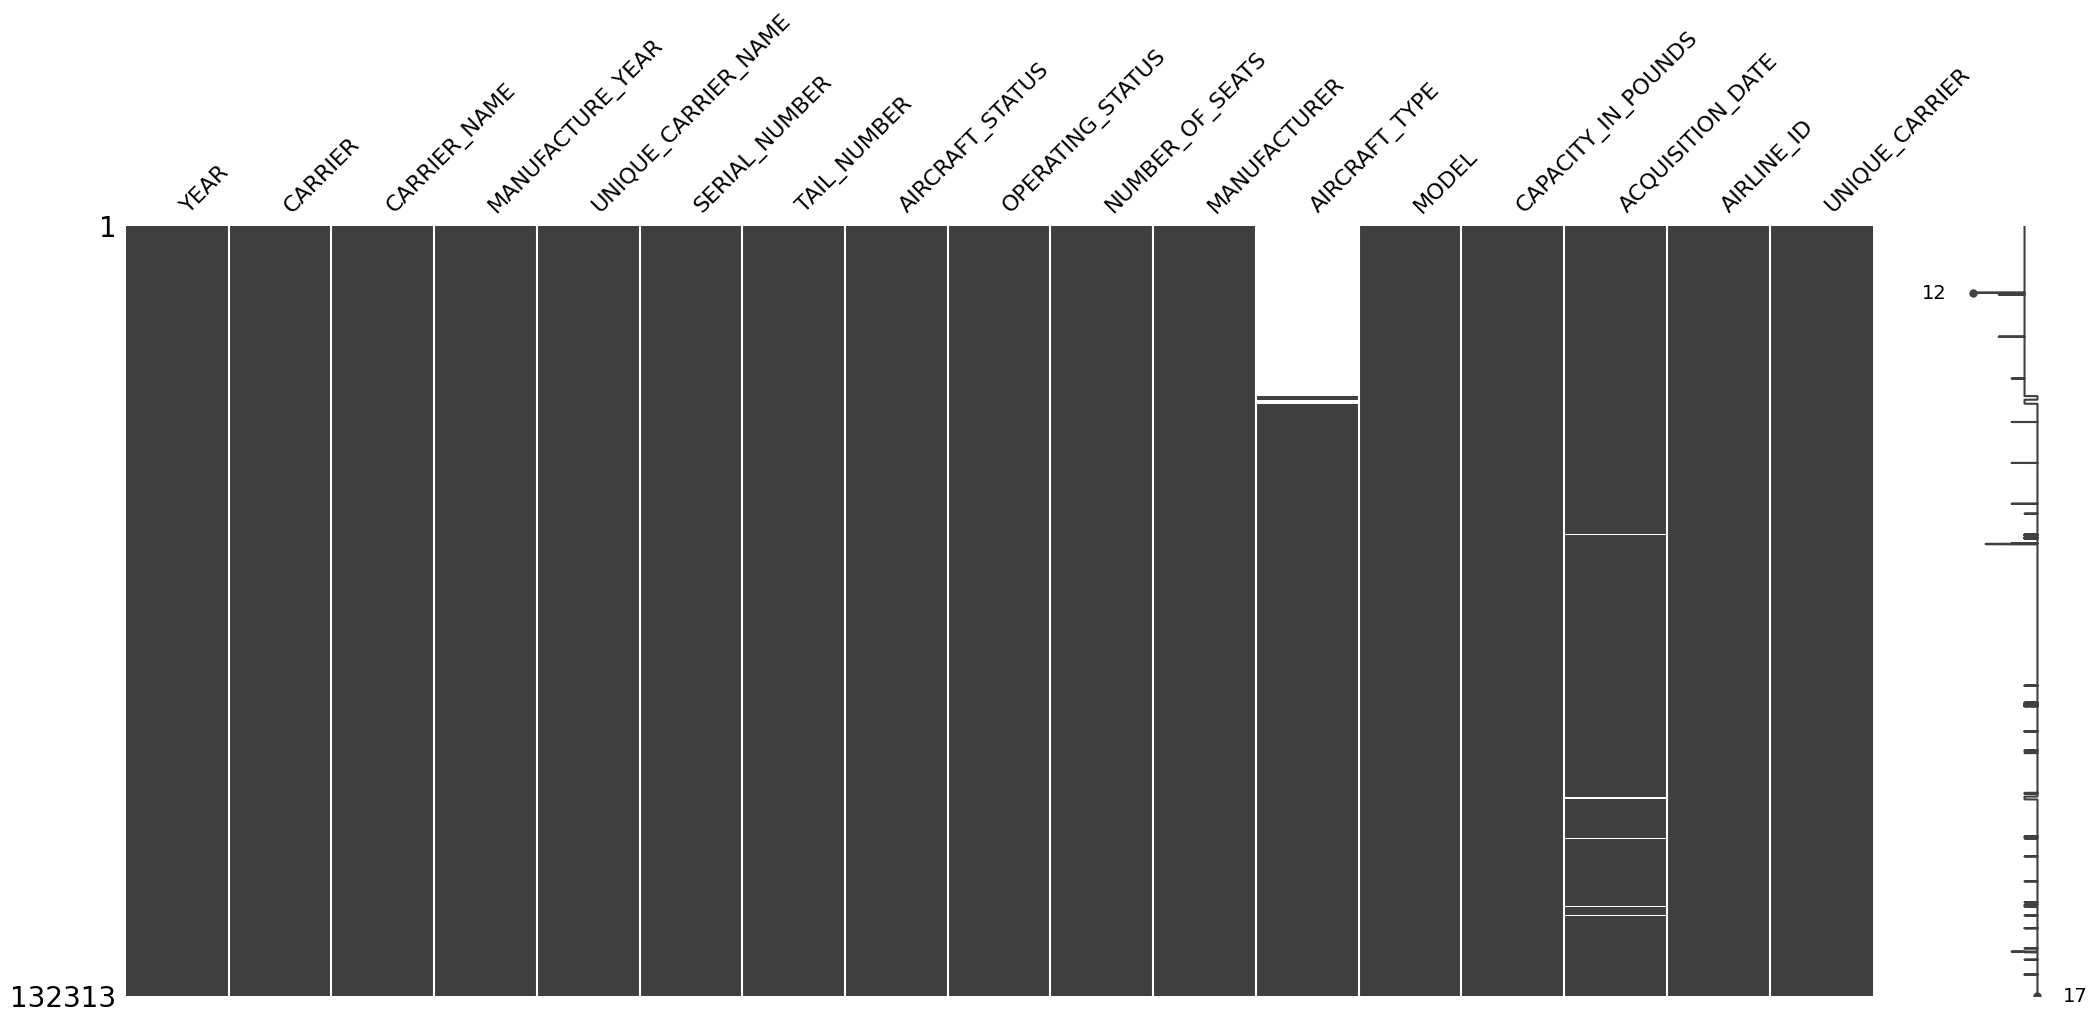

In [10]:
import missingno as msno
msno.matrix(inventory_int)

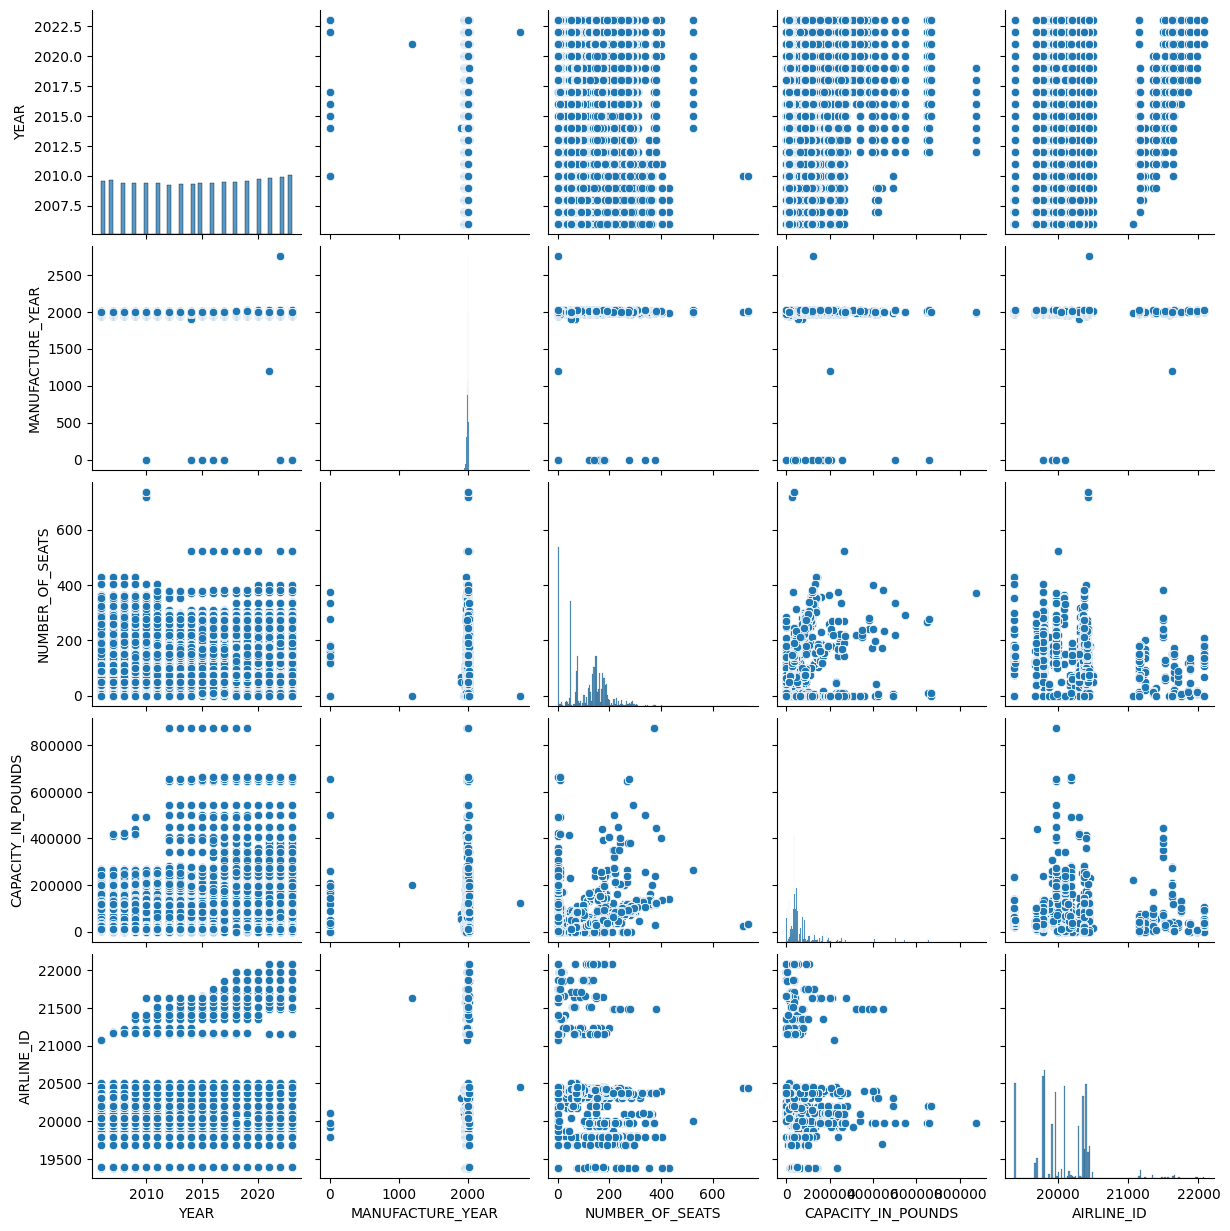

In [11]:
import seaborn as sns
sns.pairplot(inventory_int)

In [12]:
inventory_int['CARRIER'].value_counts()

CARRIER
AA     14374
DL     13761
FX     11689
UA     11547
WN     11129
       ...  
SI         3
XP         3
23Q        2
AQ         1
PM         1
Name: count, Length: 177, dtype: int64

In [13]:
inventory_int['CARRIER_NAME'].value_counts()

CARRIER_NAME
American Airlines Inc.                15047
Delta Air Lines Inc.                  14226
Federal Express Corporation           12356
United Air Lines Inc.                 11984
Southwest Airlines Co.                11639
                                      ...  
ExpressJet Airlines LLC d/b/a aha!        4
Cargo 360, Inc.                           3
Primaris Airlines Inc.                    3
Orange Air                                3
Songbird Airways Inc.                     2
Name: count, Length: 133, dtype: int64

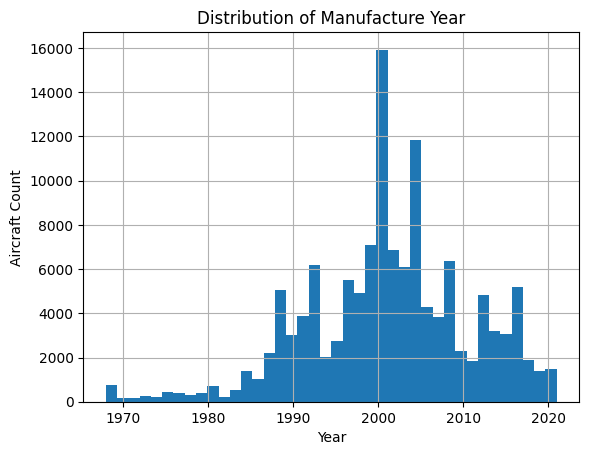

In [14]:
col = inventory_int['MANUFACTURE_YEAR']
lower, upper = col.quantile([0.01, 0.99])
col.hist(bins=40, range=(lower, upper))
plt.title("Distribution of Manufacture Year")
plt.xlabel("Year")
plt.ylabel("Aircraft Count")
plt.show()


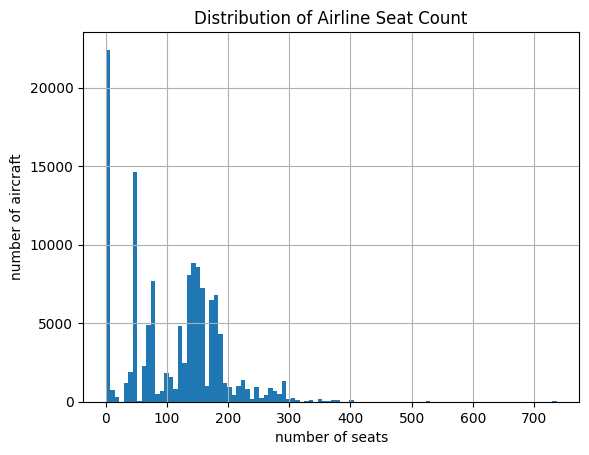

In [15]:
inventory_int['NUMBER_OF_SEATS'].hist(bins=100)
plt.title("Distribution of Airline Seat Count")
plt.xlabel("number of seats")
plt.ylabel("number of aircraft")
plt.show()

In [16]:
def filter_carrier(df, carrier_name):
    return df[df['CARRIER_NAME'] == carrier_name]

def set_carrier(df, carrier_name, carrier_code, unique_carrier = None):
    newdf = df.copy()
    mask = newdf['CARRIER_NAME'] == carrier_name
    newdf.loc[mask, 'CARRIER'] = carrier_code
    if unique_carrier is not None:
        newdf.loc[mask, 'UNIQUE_CARRIER'] = unique_carrier
    return newdf

def set_carrier_name(df, carrier_name, carrier_code, unique_carrier = None):
    newdf = df.copy()
    mask = newdf['CARRIER'] == carrier_code
    newdf.loc[mask, 'CARRIER_NAME'] = carrier_name
    if unique_carrier is not None:
        newdf.loc[mask, 'UNIQUE_CARRIER'] = unique_carrier
    return newdf

def set_unique_carrier_by_name(df, carrier_name, unique_carrier):
    newdf = df.copy()
    mask = newdf['CARRIER_NAME'] == carrier_name
    newdf.loc[mask, 'UNIQUE_CARRIER'] = unique_carrier
    return newdf

def set_unique_carrier_by_code(df, carrier_code, unique_carrier):
    newdf = df.copy()
    mask = newdf['CARRIER'] == carrier_code
    newdf.loc[mask, 'UNIQUE_CARRIER'] = unique_carrier
    return newdf

## Imputation

### Carrier
- Some `CARRIER` values for North American Airlines were NaN, some were "NA". "NA" is presumably the correct value, so we can impute the missing columns with a constant value.

In [102]:
inventory_int[inventory_int["CARRIER"].isna()]["CARRIER_NAME"].value_counts()

CARRIER_NAME
North American Airlines    49
Name: count, dtype: int64

In [17]:
# some CARRIER values for North American Airlines were NaN, some were "NaN", some were "NA".
# "NA" is presumably the correct version --> apply that value to all rows.

naa_inventory = filter_carrier(inventory_int, "North American Airlines")
print(len(naa_inventory))
print()

impute_carrier = set_carrier(inventory_int, "North American Airlines", "NA")
print(impute_carrier["CARRIER"].value_counts())

print(f"\nMissing CARRIER values in impute_carrier: {impute_carrier['CARRIER'].isna().sum()}")
print(f"CARRIER values for 'North American Airlines' rows:")
print(impute_carrier[impute_carrier['CARRIER_NAME'] == 'North American Airlines']['CARRIER'].value_counts())


59

CARRIER
AA     14374
DL     13761
FX     11689
UA     11547
WN     11129
       ...  
SI         3
XP         3
23Q        2
AQ         1
PM         1
Name: count, Length: 177, dtype: int64

Missing CARRIER values in impute_carrier: 0
CARRIER values for 'North American Airlines' rows:
CARRIER
NA    59
Name: count, dtype: int64


### CARRIER_NAME

- There are missing `CARRIER_NAME` fields for rows where `CARRIER = "L4" or "OH"`.

In [18]:
# looks like we have missing carrier names for codes OH and L4

no_carrier_name = impute_carrier[impute_carrier["CARRIER_NAME"].isna()] 
no_carrier_name["CARRIER"].value_counts()

CARRIER
OH    97
L4     8
Name: count, dtype: int64

In [19]:
# Upon inspecting the data, L4 corresponds to Carrier Name "Lynx Aviation d/b/a Frontier Airlines"
# And also a unique carrier column of "L3"

l4_carrier = impute_carrier[impute_carrier["CARRIER"] == "L4"]
print(len(l4_carrier))
print(l4_carrier['CARRIER_NAME'].head(20))

impute_l4 = set_carrier_name(
    impute_carrier, 
    "Lynx Aviation d/b/a Frontier Airlines",
    "L4",
    unique_carrier="L3"
)

impute_l4["CARRIER_NAME"].isna().sum()

18
11465                                      NaN
11466                                      NaN
11467                                      NaN
11468                                      NaN
11469                                      NaN
11470                                      NaN
11471                                      NaN
11472                                      NaN
18739    Lynx Aviation d/b/a Frontier Airlines
18740    Lynx Aviation d/b/a Frontier Airlines
18741    Lynx Aviation d/b/a Frontier Airlines
18742    Lynx Aviation d/b/a Frontier Airlines
18743    Lynx Aviation d/b/a Frontier Airlines
18744    Lynx Aviation d/b/a Frontier Airlines
18745    Lynx Aviation d/b/a Frontier Airlines
18746    Lynx Aviation d/b/a Frontier Airlines
18747    Lynx Aviation d/b/a Frontier Airlines
18748    Lynx Aviation d/b/a Frontier Airlines
Name: CARRIER_NAME, dtype: object


np.int64(97)

In [20]:
oh_carrier = impute_carrier[impute_carrier["CARRIER"] == "OH"]
print(len(oh_carrier))
oh_carrier["CARRIER_NAME"].value_counts()

1896


CARRIER_NAME
PSA Airlines Inc.    1176
Comair Inc.           623
Name: count, dtype: int64

In [21]:
#oh_carrier[oh_carrier["CARRIER_NAME"].isna()]
# Comair Inc. needs a unique Carrier Name of OH (1)
# PSA Airlines already claimed the unique carrier code OH
# The table description says different carriers must have unique carrier ids...
# I can't find a single PSA Airlines aircraft that has a unique OH (1), but 
# I am still able to find Comair aircraft that have OH (1), so I am assuming Comair should
# be distinguished by a unique carrier code of OH (1) rather than vice versa.

oh_carrier.sample(20)

impute_oh = set_unique_carrier_by_name(
    impute_l4, "Comair Inc.", "OH (1)"
)

# Initially tried this, then decided against it because it overwrote
# some PSA Airlines entries that had a separate carrier code of '16'
# impute_oh = set_unique_carrier_by_name(
#     impute_oh, "PSA Airlines Inc.", "OH"
# )

In [22]:
# Check after imputing missing aircraft values
inventory_impute = impute_oh
inventory_impute[inventory_impute["CARRIER"].isna()]["CARRIER_NAME"].value_counts()

Series([], Name: count, dtype: int64)

- I opted not to impute missing `CARRIER_NAME` for fields with `CARRIER = "OH"`, because I could not determine a reliable way to decide between the two possible airlines each could be.

In [23]:
inventory_impute.isna().sum()

YEAR                       0
CARRIER                    0
CARRIER_NAME              97
MANUFACTURE_YEAR           3
UNIQUE_CARRIER_NAME      105
SERIAL_NUMBER              0
TAIL_NUMBER                0
AIRCRAFT_STATUS            0
OPERATING_STATUS           0
NUMBER_OF_SEATS            7
MANUFACTURER               0
AIRCRAFT_TYPE          29933
MODEL                     11
CAPACITY_IN_POUNDS       101
ACQUISITION_DATE         967
AIRLINE_ID               105
UNIQUE_CARRIER           156
dtype: int64

### MANUFACTURE_YEAR

- There are only 3 missing `MANUFACTURE_YEAR` values. I think it would be ok to drop just these 3, but I will see if it is possible to correlate `YEAR` and `MANUFACTURE_YEAR` after removing outlier `MANUFACTURE_YEAR`s (> 2026 or less than 19XX doesn't make sense).

Correlation between YEAR and MANUFACTURE_YEAR: 0.4261


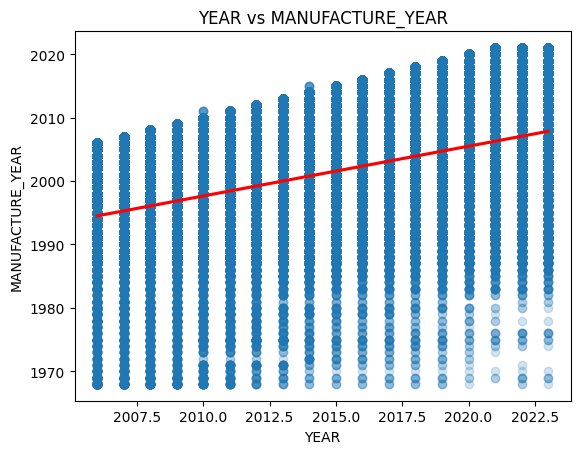

In [24]:
# Correlation plot between YEAR and MANUFACTURE_YEAR

def remove_outliers(df, column, lower_pctl, upper_pctl):
    lower_bound, upper_bound = df[column].quantile([lower_pctl, upper_pctl])    
    newdf = df.copy()
    newdf = newdf[newdf[column].between(lower_bound, upper_bound)]
    return newdf

df_remove_outliers = remove_outliers(inventory_impute, 'MANUFACTURE_YEAR', 0.01, 0.99)

xcol, ycol = 'YEAR', 'MANUFACTURE_YEAR'
df_corr = df_remove_outliers

pair_df = df_corr[[xcol, ycol]].dropna()
corr_val = pair_df[xcol].corr(pair_df[ycol])
print(f"Correlation between {xcol} and {ycol}: {corr_val:.4f}")

sns.regplot(data=pair_df, x=xcol, y=ycol, scatter_kws={'alpha': 0.2}, line_kws={'color': 'red'})
plt.title(f"{xcol} vs {ycol}")
plt.show()

Ok, I am just going to drop the 3 rows since it is such a small subset, and some have suspicious 0.0 fields for seat number and pound capacity, as well as NaN acquisition dates.

In [25]:
def drop_na_manufacture_year(df: pd.DataFrame): 
    return df.dropna(subset=["MANUFACTURE_YEAR"])

inventory_impute[inventory_impute['MANUFACTURE_YEAR'].isna()]

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
116651,2022,5Y,Atlas Air Inc.,<NA>,Atlas Air Inc.,26259,N664GT,B,Y,0,BOEING,8192,B747-400,0.0,1/25/2022 12:00:00 AM,20007,5Y
124680,2023,9E,Endeavor Air Inc.,<NA>,Endeavor Air Inc.,10134,N655CA,O,Y,69,BOMBARDIER,6311,CL-600-2C10,18055.0,NaN,20363,9E
124681,2023,9E,Endeavor Air Inc.,<NA>,Endeavor Air Inc.,10182,N690CA,O,N,69,BOMBARDIER,6311,CL-600-2C10,18055.0,NaN,20363,9E


In [26]:
df_drop_na_manyear = drop_na_manufacture_year(inventory_impute)

### NUMBER_OF_SEATS

- There are 7 missing seat counts, all from BOEING. The model name hints at having little-to-no seating with "CARGO" being in the name...

In [27]:
mask = inventory_impute['NUMBER_OF_SEATS'].isna()

missing_seats = mask.sum()
print(f"Missing NUMBER_OF_SEATS: {missing_seats}")
inventory_impute[mask]

Missing NUMBER_OF_SEATS: 7


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
97550,2019,M6,Amerijet International,1982,Amerijet International,22218,N743AX,b,Y,<NA>,BOEING,6252,767-232SFCARGO,96000.0,7/1/2010 12:00:00 AM,20151,M6
97551,2019,M6,Amerijet International,1988,Amerijet International,24146,N316CM,b,Y,<NA>,BOEING,6262,767-338ERCARGO,118000.0,8/19/2014 12:00:00 AM,20151,M6
97552,2019,M6,Amerijet International,1988,Amerijet International,24407,N319CM,b,Y,<NA>,BOEING,6262,767-338ERCARGO,118000.0,9/29/2014 12:00:00 AM,20151,M6
97553,2019,M6,Amerijet International,1990,Amerijet International,24929,N373CM,b,Y,<NA>,BOEING,6262,767-338ERCARGO,118000.0,7/15/2016 12:00:00 AM,20151,M6
97554,2019,M6,Amerijet International,1991,Amerijet International,25195,N396CM,b,Y,<NA>,BOEING,6262,767-323ERCARGO,118000.0,11/29/2017 12:00:00 AM,20151,M6
97555,2019,M6,Amerijet International,1993,Amerijet International,26995,N347CM,b,Y,<NA>,BOEING,6262,767-323ERCARGO,118000.0,10/12/2018 12:00:00 AM,20151,M6
97556,2019,M6,Amerijet International,1994,Amerijet International,27184,N378CX,b,Y,<NA>,BOEING,6262,767-323ERCARGO,118000.0,6/8/2018 12:00:00 AM,20151,M6


Yeah, sure enough when I check all the aircraft that match the following model, they have 0 seats. This can also be cross-referenced online...
https://flycraft.com/aircraft/n317cm

I am going to fill NA values with 0, as cargo aircraft have no seating.

In [28]:
inventory_impute[inventory_impute["MODEL"] == "767-338ERCARGO"].sample(10)

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
97553,2019,M6,Amerijet International,1990,Amerijet International,24929,N373CM,b,Y,<NA>,BOEING,6262,767-338ERCARGO,118000.0,7/15/2016 12:00:00 AM,20151,M6
82884,2017,M6,Amerijet International,1988,Amerijet International,24146,N316CM,b,Y,0,BOEING,6262,767-338ERCARGO,118000.0,8/19/2014 12:00:00 AM,20151,M6
97551,2019,M6,Amerijet International,1988,Amerijet International,24146,N316CM,b,Y,<NA>,BOEING,6262,767-338ERCARGO,118000.0,8/19/2014 12:00:00 AM,20151,M6
68641,2015,M6,Amerijet International,1988,Amerijet International,24146,N316CM,b,Y,0,BOEING,6262,767-338ERCARGO,118000.0,8/19/2014 12:00:00 AM,20151,M6
82886,2017,M6,Amerijet International,1990,Amerijet International,24929,N373CM,b,Y,0,BOEING,6262,767-338ERCARGO,118000.0,7/15/2016 12:00:00 AM,20151,M6
97552,2019,M6,Amerijet International,1988,Amerijet International,24407,N319CM,b,Y,<NA>,BOEING,6262,767-338ERCARGO,118000.0,9/29/2014 12:00:00 AM,20151,M6
61296,2014,M6,Amerijet International,1988,Amerijet International,24146,N316CM,b,Y,0,BOEING,6262,767-338ERCARGO,118000.0,8/19/2014 12:00:00 AM,20151,M6
90250,2018,M6,Amerijet International,1990,Amerijet International,24929,N373CM,b,Y,0,BOEING,6262,767-338ERCARGO,118000.0,7/15/2016 12:00:00 AM,20151,M6
105017,2020,M6,Amerijet International,1988,Amerijet International,24146,N316CM,b,Y,0,BOEING,6262,767-338ERCARGO,118000.0,8/19/2014 12:00:00 AM,20151,M6
75745,2016,M6,Amerijet International,1990,Amerijet International,24929,N373CM,b,Y,0,BOEING,6262,767-338ERCARGO,118000.0,6/27/2016 12:00:00 AM,20151,M6


In [29]:
def cargo_models_no_seating(df: pd.DataFrame):
    newdf = df.copy()
    mask = df["NUMBER_OF_SEATS"].isna()
    # maybe inefficient to do .str.contains, but I wanted to be able to detect other
    # models that weren't the two boeing models specified just in case...
    cargo_mask = newdf["MODEL"].str.contains("CARGO", case=False, na=False)
    newdf.loc[mask & cargo_mask, "NUMBER_OF_SEATS"] = 0
    return newdf

In [30]:
df_cargo_no_seating = cargo_models_no_seating(df_drop_na_manyear)
df_cargo_no_seating.isna().sum()

YEAR                       0
CARRIER                    0
CARRIER_NAME              97
MANUFACTURE_YEAR           0
UNIQUE_CARRIER_NAME      105
SERIAL_NUMBER              0
TAIL_NUMBER                0
AIRCRAFT_STATUS            0
OPERATING_STATUS           0
NUMBER_OF_SEATS            0
MANUFACTURER               0
AIRCRAFT_TYPE          29933
MODEL                     11
CAPACITY_IN_POUNDS       101
ACQUISITION_DATE         965
AIRLINE_ID               105
UNIQUE_CARRIER           156
dtype: int64

### CAPACITY_IN_POUNDS

- My first instinct is to explore how many unique aircraft models there are, and impute the median value for each model with a missing capacity.

In [31]:
mask = df_cargo_no_seating['CAPACITY_IN_POUNDS'].isna()

missing_lbs = mask.sum()
print(f"Missing CAPACITY_IN_POUNDS: {missing_lbs}")
df_cargo_no_seating[mask]

Missing CAPACITY_IN_POUNDS: 101


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
78991,2017,5Y,Atlas Air Inc.,1982,Atlas Air Inc.,22694,N767MW,b,Y,181,BOEING,6251,B767-200,NaN,7/1/2013 12:00:00 AM,20007,5Y
79015,2017,5Y,Atlas Air Inc.,2012,Atlas Air Inc.,37809,N643GT,b,Y,0,BOEING,6262,B767-300,NaN,1/17/2013 12:00:00 AM,20007,5Y
79016,2017,5Y,Atlas Air Inc.,2012,Atlas Air Inc.,37810,N644GT,b,Y,0,BOEING,6262,B767-300,NaN,1/22/2013 12:00:00 AM,20007,5Y
81902,2017,FX,Federal Express Corporation,1971,Federal Express Corporation,46601,N365FE,O,Y,0,MCDONNELLDOUGLAS,7302,DC-10-10,NaN,11/6/1997 12:00:00 AM,20107,FX
81903,2017,FX,Federal Express Corporation,1971,Federal Express Corporation,46606,N368FE,O,Y,0,MCDONNELLDOUGLAS,7302,DC-10-10,NaN,8/21/1997 12:00:00 AM,20107,FX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82456,2017,FX,Federal Express Corporation,1999,Federal Express Corporation,48791,N620FE,b,Y,0,MCDONNELLDOUGLAS,7402,MD-11,NaN,3/25/1999 12:00:00 AM,20107,FX
82457,2017,FX,Federal Express Corporation,1999,Federal Express Corporation,48792,N621FE,b,Y,0,MCDONNELLDOUGLAS,7402,MD-11,NaN,5/28/1999 12:00:00 AM,20107,FX
82458,2017,FX,Federal Express Corporation,1999,Federal Express Corporation,48794,N623FE,b,Y,0,MCDONNELLDOUGLAS,7402,MD-11,NaN,6/28/1999 12:00:00 AM,20107,FX
90567,2018,NK,Spirit Air Lines,2018,Spirit Air Lines,8658,N908NK,b,Y,182,AirbusIndustries,7221,A-320-PSGRneo,NaN,12/17/2018 12:00:00 AM,20416,NK


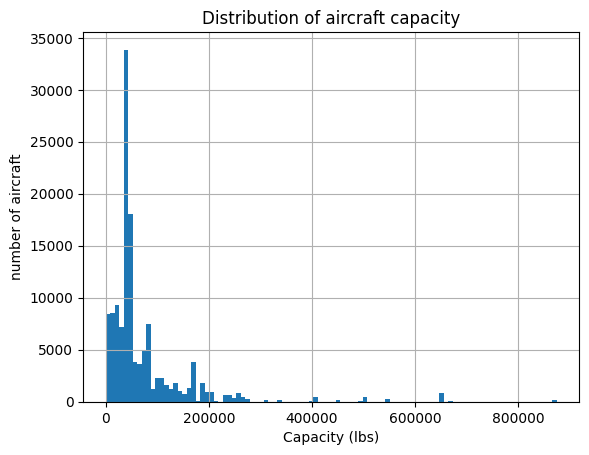

In [32]:
df_cargo_no_seating['CAPACITY_IN_POUNDS'].hist(bins=100)
plt.title("Distribution of aircraft capacity")
plt.xlabel("Capacity (lbs)")
plt.ylabel("number of aircraft")
plt.show()

In [33]:
df_cargo_no_seating['MODEL'].value_counts()

MODEL
EMB-145          2614
B-737-7H4        2470
B737-823         2370
A320-232         2333
A321-231         2259
                 ... 
A321-231(P2F)       1
777FFX              1
T210N               1
757-29J             1
757-260PF           1
Name: count, Length: 1340, dtype: int64

In [100]:
# the list of models with missing CAPACITY_IN_POUNDS entries
missing_models = df_cargo_no_seating.loc[mask, 'MODEL'].unique()
print(missing_models)

def get_model_stats(missing_models):
    mask = df_cargo_no_seating['MODEL'].isin(missing_models)
    amt_mask = df_cargo_no_seating['CAPACITY_IN_POUNDS'] > 0
    # get the median and impute
    capacity_stats = (
        df_cargo_no_seating[mask & amt_mask]
        .groupby('MODEL')['CAPACITY_IN_POUNDS']
        .agg(['mean', 'median'])
        .sort_index()
    )
    return capacity_stats

capacity_stats = get_model_stats(missing_models)
capacity_stats

['B767-200' 'B767-300' 'DC-10-10' 'DC-10-30' 'MD-11' 'A-320-PSGRneo']


,mean,median
MODEL,,
A-320-PSGRneo,35600.000000,35600.0
B767-200,218937.217391,213390.0
B767-300,237756.000000,237756.0
DC-10-10,137895.511182,137907.0
DC-10-30,167529.276596,163122.0
MD-11,194319.101713,194036.0


In [101]:
# impute missing CAPACITY_IN_POUNDS by model median from capacity_stats
def impute_median_capacity(df, capacity_stats):
    median_map = capacity_stats['median'].to_dict()
    df_capacity_imputed = df_cargo_no_seating.copy()
    df_capacity_imputed.loc[mask, 'CAPACITY_IN_POUNDS'] = (
        df_capacity_imputed.loc[mask, 'MODEL'].map(median_map)
    )
    return df_capacity_imputed

df_capacity_imputed = impute_median_capacity(df_cargo_no_seating, capacity_stats)
df_capacity_imputed.isna().sum()

YEAR                       0
CARRIER                    0
CARRIER_NAME              97
MANUFACTURE_YEAR           0
UNIQUE_CARRIER_NAME      105
SERIAL_NUMBER              0
TAIL_NUMBER                0
AIRCRAFT_STATUS            0
OPERATING_STATUS           0
NUMBER_OF_SEATS            0
MANUFACTURER               0
AIRCRAFT_TYPE          29933
MODEL                     11
CAPACITY_IN_POUNDS         0
ACQUISITION_DATE         965
AIRLINE_ID               105
UNIQUE_CARRIER           156
dtype: int64

### AIRLINE_ID

<Axes: >

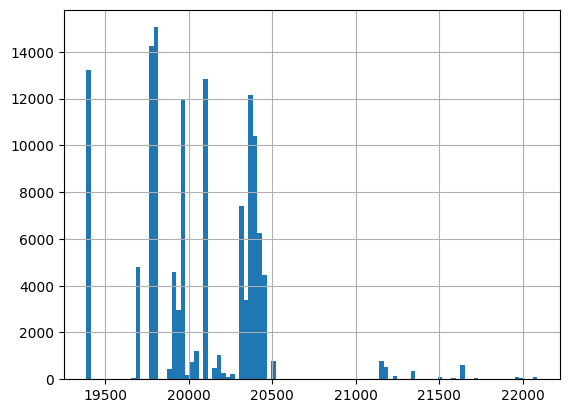

In [36]:
df_capacity_imputed['AIRLINE_ID'].hist(bins=100)

In [37]:
mask_na = df_capacity_imputed['AIRLINE_ID'].isna()
print(df_capacity_imputed[mask_na]['CARRIER_NAME'].value_counts())
df_capacity_imputed[mask_na]

CARRIER_NAME
Lynx Aviation d/b/a Frontier Airlines    8
Name: count, dtype: int64


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
11465,2007,L4,Lynx Aviation d/b/a Frontier Airlines,2007,NaN,4165,N501LX,B,Y,74,DEHAVILLAND,NaN,DASH8-Q4,19000.0,7/19/2007 12:00:00 AM,<NA>,L3
11466,2007,L4,Lynx Aviation d/b/a Frontier Airlines,2007,NaN,4168,N502LX,O,Y,74,DEHAVILLAND,NaN,DASH8-Q4,19000.0,8/28/2007 12:00:00 AM,<NA>,L3
11467,2007,L4,Lynx Aviation d/b/a Frontier Airlines,2007,NaN,4170,N503LX,B,Y,74,DEHAVILLAND,NaN,DASH8-Q4,19000.0,10/12/2007 12:00:00 AM,<NA>,L3
11468,2007,L4,Lynx Aviation d/b/a Frontier Airlines,2007,NaN,4172,N504LX,B,Y,74,DEHAVILLAND,NaN,DASH8-Q4,19000.0,10/19/2007 12:00:00 AM,<NA>,L3
11469,2007,L4,Lynx Aviation d/b/a Frontier Airlines,2007,NaN,4174,N505LX,B,Y,74,DEHAVILLAND,NaN,DASH8-Q4,19000.0,10/25/2007 12:00:00 AM,<NA>,L3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54702,2013,OH,NaN,2008,NaN,15157,N538CA,O,Y,76,BOMBARDIER,6381,CRJ900-Passanger,75000.0,1/11/2008 12:00:00 AM,<NA>,NaN
54703,2013,OH,NaN,2008,NaN,15159,N548CA,O,Y,76,BOMBARDIER,6381,CRJ900-Passanger,75000.0,1/28/2008 12:00:00 AM,<NA>,NaN
54704,2013,OH,NaN,2008,NaN,15164,N549CA,O,Y,76,BOMBARDIER,6381,CRJ900-Passanger,75000.0,2/29/2008 12:00:00 AM,<NA>,NaN
54705,2013,OH,NaN,2008,NaN,15168,N554CA,O,Y,76,BOMBARDIER,6381,CRJ900-Passanger,75000.0,3/20/2008 12:00:00 AM,<NA>,NaN


It looks like most missing `AIRLINE_ID` values are also in the `CARRIER = OH` entries. I will see if I can get airline ID values from other entries that match the carrier name or carrier.

In [38]:
# carriers that have at least one missing AIRLINE_ID
carriers_with_na_airline = (
    inventory_impute[inventory_impute['AIRLINE_ID'].isna()]['CARRIER']
    .dropna()
    .unique()
)

# value counts of airline id for those carriers
df_airline_id_counts = (
    inventory_impute[inventory_impute['CARRIER'].isin(carriers_with_na_airline)]
    .groupby(['CARRIER', 'AIRLINE_ID'], dropna=False)
    .size()
    .reset_index(name='count')
    .sort_values(['CARRIER', 'count'], ascending=[True, False])
)

df_airline_id_counts

,CARRIER,AIRLINE_ID,count
0,L4,21217,10
1,L4,<NA>,8
2,OH,20397,1176
3,OH,20417,623
4,OH,<NA>,97


Unless I am missing something, I don't know how to determine which entries would get which of the two possible `AIRLINE_ID` values for `OH` carriers (same problem as `CARRIER_NAME` I dealt with earlier), so I am going to keep omitting those for now. On the other hand, it looks like the missing airline IDs for `L4` carriers can be safely imputed to be `21217`.

In [39]:
def impute_l4_ids(df):
    newdf = df.copy()
    mask = newdf['CARRIER'] == "L4"
    mask_na = newdf[mask].isna()
    newdf[mask_na] = 21217
    return newdf

In [40]:
df_airline_id_imputed = impute_l4_ids(df_capacity_imputed)
df_airline_id_imputed.isna().sum()

YEAR                       0
CARRIER                    0
CARRIER_NAME              97
MANUFACTURE_YEAR           0
UNIQUE_CARRIER_NAME       97
SERIAL_NUMBER              0
TAIL_NUMBER                0
AIRCRAFT_STATUS            0
OPERATING_STATUS           0
NUMBER_OF_SEATS            0
MANUFACTURER               0
AIRCRAFT_TYPE          29915
MODEL                     11
CAPACITY_IN_POUNDS         0
ACQUISITION_DATE         965
AIRLINE_ID                97
UNIQUE_CARRIER           156
dtype: int64

# Task 2

In [41]:
df_final_imputed = df_airline_id_imputed.copy()

### Manufacturer

In [42]:
df_final_imputed['MANUFACTURER'].value_counts().head(20)

MANUFACTURER
BOEING                                                                              15921
Embraer                                                                             11508
THEBOEINGCO                                                                          9223
Bombardier                                                                           8871
Boeing                                                                               8392
BoeingCo                                                                             7446
AIRBUS                                                                               7179
AirbusIndustries                                                                     6967
BOEINGCOMPANY                                                                        6767
Airbus                                                                               5289
CESSNA                                                                               41

Make case insensitive, unify as many aliases as possible, remove special characters, ...
- boeing, Boeing, BOEING, TheBoeingCompany, THEBOEINGCOMPANY, etc.. --> BOEING
- airbus, Airbus, AIRBUS, AirbusIndustrie, AIRBUSINDUSTRIES, etc.. --> AIRBUS

I attempted to get as many big wins as as I could, and a few small ones, but there will inevitably be ones I missed. If I was unsure whether to count it as the same airline, I skipped it.

In [43]:
def remove_special_chars_manufacturer(df: pd.DataFrame):
    newdf = df.copy()
    # regex removes all special characters
    newdf['MANUFACTURER'] = newdf['MANUFACTURER'].str.replace(r'[^A-Za-z0-9]', '', regex=True)
    return newdf

def uppercase_manufacturer(df: pd.DataFrame) -> pd.DataFrame:
    newdf = df.copy()
    newdf['MANUFACTURER'] = newdf['MANUFACTURER'].str.upper()
    return newdf

def replace_manufacturer_substring(df: pd.DataFrame, substr: str, replacement=None) -> pd.DataFrame:
    newdf = df.copy()
    mask = newdf['MANUFACTURER'].str.contains(substr, case=False, na=False)
    newdf.loc[mask, 'MANUFACTURER'] = replacement if replacement else substr
    return newdf

In [44]:
df_manufacture = remove_special_chars_manufacturer(df_final_imputed)
df_manufacture = uppercase_manufacturer(df_manufacture)
df_manufacture = replace_manufacturer_substring(df_manufacture, "BOEING")
df_manufacture = replace_manufacturer_substring(df_manufacture, "AIRBUS")
df_manufacture = replace_manufacturer_substring(df_manufacture, "BOMBARDIER")
df_manufacture = replace_manufacturer_substring(df_manufacture, "DASSAULT")
df_manufacture = replace_manufacturer_substring(df_manufacture, "EASYJET")
df_manufacture = replace_manufacturer_substring(df_manufacture, "FOKKER")
df_manufacture = replace_manufacturer_substring(df_manufacture, "FGLAIR", "FGLAIRCRAFT")
df_manufacture = replace_manufacturer_substring(df_manufacture, "GULFSTREAM", "GULFSTREAMAEROSPACE")
df_manufacture = replace_manufacturer_substring(df_manufacture, "LEAR", "LEARJET")
df_manufacture = replace_manufacturer_substring(df_manufacture, "MCDO", "MCDONNELLDOUGLAS")
df_manufacture = replace_manufacturer_substring(df_manufacture, "SAAB")
df_manufacture = replace_manufacturer_substring(df_manufacture, "DOUGLAS AIRCRAFT", "DOUGLAS")

In [45]:
print(df_manufacture['MANUFACTURER'].value_counts().sort_index().head(30))

MANUFACTURER
AERCAP                   13
AERCAPFRONTIER            2
AERLINGUSGECAS            4
AEROAERI                  4
AEROFLOTGECAS             6
AEROSPATIALE             20
AGUSTAWESTLAND            7
AIRBUS                23517
ALC                       4
ALCALASKA                16
ALITALIAREALIS           16
AMAEXPR                   1
ATR                    1181
AVIANCAACG               21
AVOLON                    4
AVOLONPEACH               4
B757223                   1
BAE                      26
BEECHCRAFT                3
BEECHHAWKER400XP          1
BELL                      2
BOEING                55638
BOMBARDIER            12481
CALC                      2
CANADAIR               3861
CASA                     21
CDBACEBUPACIFIC           2
CEBUPACIFIC              43
CEBUPACIFICJPLEASE        8
CEBUPACIFICSMBC          12
Name: count, dtype: int64


### Model

In [46]:
def remove_special_chars_model(df: pd.DataFrame):
    newdf = df.copy()
    # regex removes all special characters
    newdf['MODEL'] = newdf['MODEL'].str.replace(r'[^A-Za-z0-9]', '', regex=True)
    return newdf

def uppercase_model(df: pd.DataFrame) -> pd.DataFrame:
    newdf = df.copy()
    newdf['MODEL'] = newdf['MODEL'].str.upper()
    return newdf

def replace_model_substring(df: pd.DataFrame, substr: str, replacement=None) -> pd.DataFrame:
    newdf = df.copy()
    mask = newdf['MODEL'].str.contains(substr, case=False, na=False)
    newdf.loc[mask, 'MODEL'] = replacement if replacement else substr
    return newdf

In [47]:
df_manufacture['MODEL'].value_counts().sort_index(ascending=False)

MODEL
b767-3G5ER      3
b767-3CbER      3
b767-33aER      6
b767-332        4
b717-200       18
             ... 
208B          225
2012          133
200             3
150             2
0             706
Name: count, Length: 1340, dtype: int64

`MODEL` feels far messier than `MANUFACTURER`...

 Make case insensitive, remove special characters...
 It's unclear whether things such as `WESTWIND` and `WESTWINDI` should be the same, or things like `SUPER80PASSENGER` and `SUPER80`. I chose to only remove special characters and make all strings uppercase. 

In [48]:
df_model = remove_special_chars_model(df_manufacture)
df_model = uppercase_model(df_model)

In [49]:
df_model['MODEL'].value_counts().sample(30).sort_index(ascending=False)

MODEL
SOVEREIGN              2
MD80PAX                1
GIVX                   9
G650                  27
FALCON20               2
ERJ175100SU            5
CV640CARGO             1
CRJ700PASSANGER       45
CRJ550PSGR             8
CHAL604                1
C208                 253
BOEING767300ER        26
BOEING717200          88
B777212                1
B767341BDSF            2
B7672RPSGR             4
B76723BPSGR            1
B767231                3
B7572S7               29
B757222PAX           499
B747400              372
B737990ALLPAX        156
B737700BBJ1            1
B737300CRG             5
A319115              288
A300600RPASSENGER      9
747428BCF             22
747412                 9
747212B               14
601                    1
Name: count, dtype: int64

### Aircraft Status

In [50]:
df_final_imputed['AIRCRAFT_STATUS'].value_counts()

AIRCRAFT_STATUS
O    79485
b    30852
B    12698
a     7804
A     1330
L      122
o       19
Name: count, dtype: int64

I would expect that `AIRCRAFT_STATUS` should be case insensitive... hard to tell if uppercase/lowercase status codes mean different things though. I could see an alternative approach would be to make a new column with the transformation instead of doing it in-place to `AIRCRAFT_STATUS`.

In [51]:
def clean_aircraft_status(df: pd.DataFrame):
    newdf = df.copy()
    newdf["AIRCRAFT_STATUS"] = newdf["AIRCRAFT_STATUS"].str.upper()
    return newdf

In [52]:
df_aircraft_status = clean_aircraft_status(df_model)
df_aircraft_status["AIRCRAFT_STATUS"].value_counts()

AIRCRAFT_STATUS
O    79504
B    43550
A     9134
L      122
Name: count, dtype: int64

### Operating Status

In [53]:
df_final_imputed['OPERATING_STATUS'].value_counts()

OPERATING_STATUS
Y    126575
N      5663
y        71
          1
Name: count, dtype: int64

I would expect that `y` should be transformed to `Y`. Since the empty entry is one row and I don't want to make an assumption about the empty space (although my inclination would be it's equivalent to `N`), I will drop that row.

In [54]:
def clean_operating_status(df: pd.DataFrame):
    newdf = df.copy()
    newdf['OPERATING_STATUS'] = newdf['OPERATING_STATUS'].str.upper()
    newdf = newdf[newdf['OPERATING_STATUS'] != ' ']
    return newdf

In [55]:
df_op_status = clean_operating_status(df_aircraft_status)
df_op_status["OPERATING_STATUS"].value_counts()

OPERATING_STATUS
Y    126646
N      5663
Name: count, dtype: int64

# Task 3

In [56]:
df_final_task2 = df_op_status
df_final_task2.isna().sum()

YEAR                       0
CARRIER                    0
CARRIER_NAME              97
MANUFACTURE_YEAR           0
UNIQUE_CARRIER_NAME       97
SERIAL_NUMBER              0
TAIL_NUMBER                0
AIRCRAFT_STATUS            0
OPERATING_STATUS           0
NUMBER_OF_SEATS            0
MANUFACTURER               0
AIRCRAFT_TYPE          29915
MODEL                     11
CAPACITY_IN_POUNDS         0
ACQUISITION_DATE         965
AIRLINE_ID                97
UNIQUE_CARRIER           156
dtype: int64

In [57]:
df_task3 = df_final_task2.dropna()
df_task3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101292 entries, 11465 to 132312
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 101292 non-null  int64  
 1   CARRIER              101292 non-null  object 
 2   CARRIER_NAME         101292 non-null  object 
 3   MANUFACTURE_YEAR     101292 non-null  Int64  
 4   UNIQUE_CARRIER_NAME  101292 non-null  object 
 5   SERIAL_NUMBER        101292 non-null  object 
 6   TAIL_NUMBER          101292 non-null  object 
 7   AIRCRAFT_STATUS      101292 non-null  object 
 8   OPERATING_STATUS     101292 non-null  object 
 9   NUMBER_OF_SEATS      101292 non-null  Int64  
 10  MANUFACTURER         101292 non-null  object 
 11  AIRCRAFT_TYPE        101292 non-null  object 
 12  MODEL                101292 non-null  object 
 13  CAPACITY_IN_POUNDS   101292 non-null  float64
 14  ACQUISITION_DATE     101292 non-null  object 
 15  AIRLINE_ID        

**We kept 101,292 entries out of the initial 132,313...**

In [58]:
print(f"% of data retained:")
print(round(101292 / 132313 * 100, 2))

% of data retained:
76.55


# Task 4

### Histograms for `NUMBER_OF_SEATS` and `CAPACITY_IN_POUNDS`

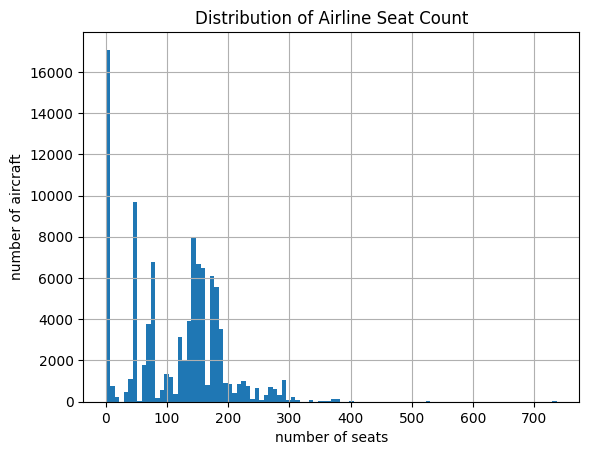

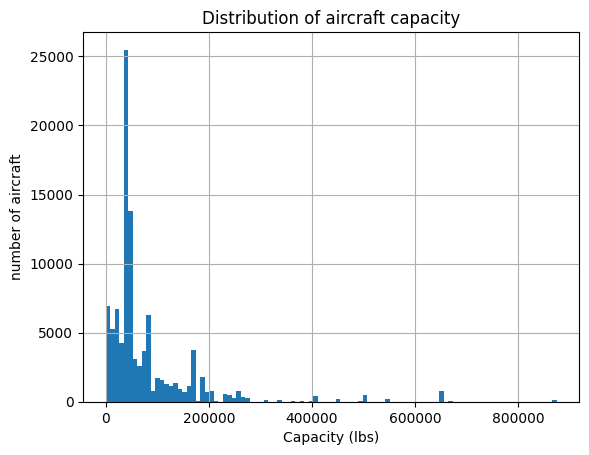

In [59]:
df_task3['NUMBER_OF_SEATS'].hist(bins=100)
plt.title("Distribution of Airline Seat Count")
plt.xlabel("number of seats")
plt.ylabel("number of aircraft")
plt.show()

df_task3['CAPACITY_IN_POUNDS'].hist(bins=100)
plt.title("Distribution of aircraft capacity")
plt.xlabel("Capacity (lbs)")
plt.ylabel("number of aircraft")
plt.show()

### Box-Cox transform

In [78]:
df_task3[['NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS']].describe()
print(len(df_task3[df_task3['NUMBER_OF_SEATS'] <= 0]))
print(len(df_task3[df_task3['CAPACITY_IN_POUNDS'] <= 0]))

16900
2268


Boxcox requires positive values in order to apply the transformation. Since there are a large number of values of 0 (~19k out of ~115k total entries), I chose to shift them by 1 rather than drop the rows so that they could still be visualized.

In [89]:
def shift_zero_vals(df: pd.DataFrame):
    newdf = df.copy()
    mask = (newdf['NUMBER_OF_SEATS'] <= 0)
    newdf.loc[mask, ['NUMBER_OF_SEATS']] += 1
    mask = (newdf['CAPACITY_IN_POUNDS'] <= 0)
    newdf.loc[mask, ['CAPACITY_IN_POUNDS']] += 1
    return newdf

def drop_zero_vals(df: pd.DataFrame):
    newdf = df.copy()
    mask = (newdf['NUMBER_OF_SEATS'] > 0) & (newdf['CAPACITY_IN_POUNDS'] > 0)
    return newdf[mask]


In [90]:
df_positive_vals = shift_zero_vals(df_task3)
df_drop_zeros = drop_zero_vals(df_task3)

In [91]:
import scipy.stats

def add_boxcox_transforms(df):
    newdf = df.copy()
    for col in ['NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS']:
        transformed, _ = scipy.stats.boxcox(df[col])
        newdf[f'{col}_BOXCOX'] = transformed
    return newdf

df_task4 = add_boxcox_transforms(df_positive_vals)
df_task4_dropzero = add_boxcox_transforms(df_drop_zeros)

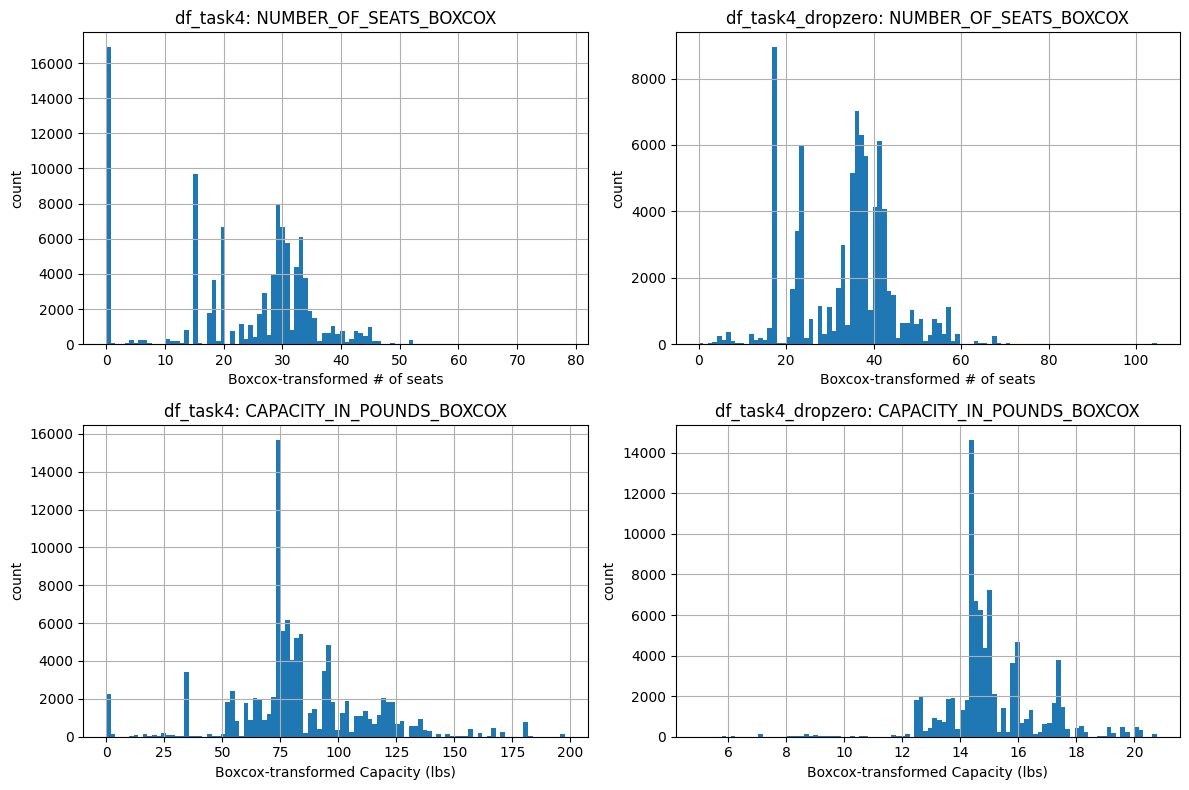

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# NUMBER_OF_SEATS_BOXCOX
df_task4['NUMBER_OF_SEATS_BOXCOX'].hist(bins=100, ax=axes[0, 0])
axes[0, 0].set_title("df_task4: NUMBER_OF_SEATS_BOXCOX")
axes[0, 0].set_xlabel("Boxcox-transformed # of seats")
axes[0, 0].set_ylabel("count")

df_task4_dropzero['NUMBER_OF_SEATS_BOXCOX'].hist(bins=100, ax=axes[0, 1])
axes[0, 1].set_title("df_task4_dropzero: NUMBER_OF_SEATS_BOXCOX")
axes[0, 1].set_xlabel("Boxcox-transformed # of seats")
axes[0, 1].set_ylabel("count")

# CAPACITY_IN_POUNDS_BOXCOX
df_task4['CAPACITY_IN_POUNDS_BOXCOX'].hist(bins=100, ax=axes[1, 0])
axes[1, 0].set_title("df_task4: CAPACITY_IN_POUNDS_BOXCOX")
axes[1, 0].set_xlabel("Boxcox-transformed Capacity (lbs)")
axes[1, 0].set_ylabel("count")

df_task4_dropzero['CAPACITY_IN_POUNDS_BOXCOX'].hist(bins=100, ax=axes[1, 1])
axes[1, 1].set_title("df_task4_dropzero: CAPACITY_IN_POUNDS_BOXCOX")
axes[1, 1].set_xlabel("Boxcox-transformed Capacity (lbs)")
axes[1, 1].set_ylabel("count")

plt.tight_layout()
plt.show()

Before transforming, both columns have a right-skewed distribution. After transforming, `NUMBER_OF_SEATS` is still rather right-skewed, especially when including the high volume of `0` seat values likely associated with non-commercial aircraft. Meanwhile, `CAPACITY_IN_POUNDS` becomes fairly normalized both with and without including `0` values. 

# Task 5

### Creating `SIZE`

In [99]:
def add_size_column(df: pd.DataFrame):
    q1, q2, q3 = df['NUMBER_OF_SEATS'].quantile([0.25, 0.50, 0.75])
    newdf = df.copy()
    newdf['SIZE'] = pd.cut(
        newdf['NUMBER_OF_SEATS'],
        bins=[-float("inf"), q1, q2, q3, float("inf")],
        labels=['SMALL', 'MEDIUM', 'LARGE', 'XLARGE'],
        include_lowest=True
    )
    return newdf

df_size = add_size_column(df_task3)
print(df_size['SIZE'].value_counts())
df_size[['NUMBER_OF_SEATS', 'SIZE']].head()

SIZE
SMALL     29317
LARGE     25687
XLARGE    24909
MEDIUM    21379
Name: count, dtype: int64


,NUMBER_OF_SEATS,SIZE
11465,74,MEDIUM
11466,74,MEDIUM
11467,74,MEDIUM
11468,74,MEDIUM
11469,74,MEDIUM


### Plot operating vs. not operating per size group

     SIZE  operating_rate
0   SMALL        0.953304
1  MEDIUM        0.959633
2   LARGE        0.967493
3  XLARGE        0.968806


C:\Users\Natha\AppData\Local\Temp\ipykernel_46432\809621997.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('SIZE')['is_operating']


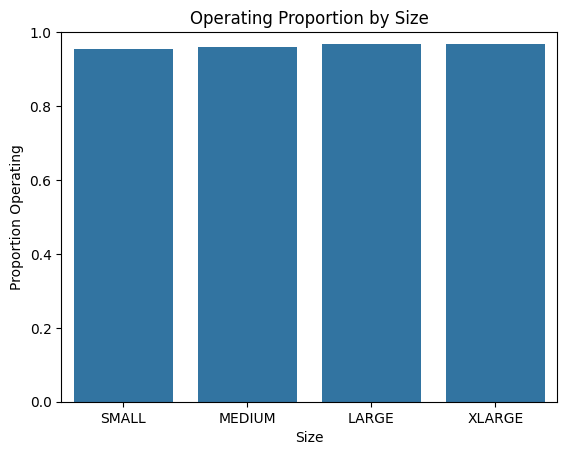

In [97]:
size_operating_rate = (
    df_size
    .assign(is_operating=df_size['OPERATING_STATUS'] == 'Y')
    .groupby('SIZE')['is_operating']
    .mean()
    .reset_index(name='operating_rate')
)

print(size_operating_rate)

ax = sns.barplot(data=size_operating_rate, x='SIZE', y='operating_rate')
ax.set_title('Operating Proportion by Size')
ax.set_ylabel('Proportion Operating')
ax.set_xlabel('Size')
plt.ylim(0, 1)
plt.show()

More than 95% of aircraft in each bin are active. There is also a small correlation between the size of the aircraft and the proportion that are active. In order of least to greatest proportion of active aircraft: 

- `SMALL` ~ 95.3%
- `MEDIUM` ~ 96.0%
- `LARGE` ~ 96.7%
- `XLARGE` ~ 96.9%

### Plot aircraft status per size group

AIRCRAFT_STATUS         A         B         L         O
SIZE                                                   
SMALL            0.039329  0.398847  0.000000  0.561824
MEDIUM           0.076337  0.417325  0.001590  0.504748
LARGE            0.115545  0.195040  0.001869  0.687546
XLARGE           0.075635  0.196234  0.001606  0.726525


C:\Users\Natha\AppData\Local\Temp\ipykernel_46432\3611400448.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['SIZE', 'AIRCRAFT_STATUS'])


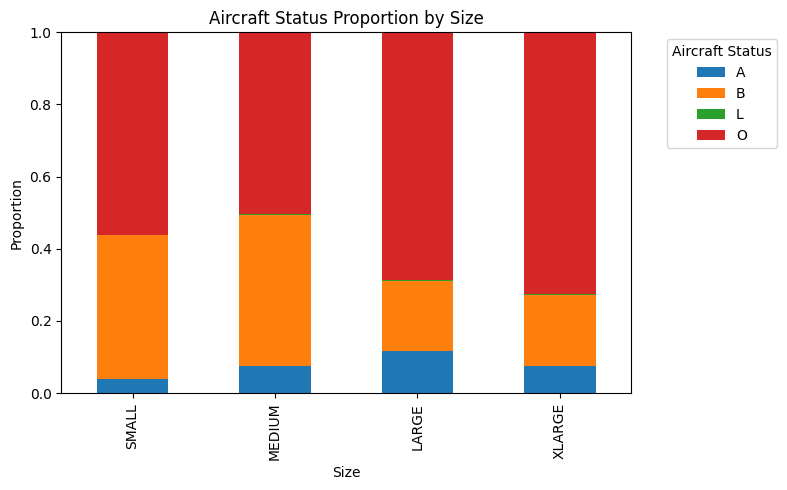

In [98]:
# Proportion of AIRCRAFT_STATUS within each SIZE group
size_status_counts = (
    df_size
    .groupby(['SIZE', 'AIRCRAFT_STATUS'])
    .size()
    .unstack(fill_value=0)
)
size_status_props = size_status_counts.div(size_status_counts.sum(axis=1), axis=0)
print(size_status_props)

# stacked bar chart of proportions
ax = size_status_props.plot(kind='bar', stacked=True, figsize=(8, 5))
ax.set_ylabel('Proportion')
ax.set_xlabel('Size')
ax.set_title('Aircraft Status Proportion by Size')
ax.set_ylim(0, 1)
ax.legend(title='Aircraft Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Status `O` is the most prevalent overall, followed by `B`, `A`, and then `L`. `XLARGE` aircraft have the highest proportion of status `O` at 72.6%, `MEDIUM` aircraft have the highest proportion of `B` at 41.2%, and `LARGE` aircraft have the highest proportion of `A` at 11.6%. Each bin has less than 0.02% of their aircrafts with status `L`, with `SMALL` aircrafts having none at all. 

`MEDIUM` and `XLARGE` have very similar proportions of status `A` (~7%), and `LARGE` and `XLARGE` aircraft have very similar proportions of status `B` (~19.5%).

# Submission guidelines
Your submission should be contained in a `homework_1` folder of your Github repository, and it should include 
- a `readme.md` file including how to run the code and what your expected outputs are (if the code is run), 
- your source code, and
- a `.pdf` or `.html` file containing your written answers.

# Generative AI disclosure

*Syllabus* policy: 

Required disclosure: each submission must include an AI Usage note stating: (1) tool(s) used, (2) the key prompt(s), and (3) what you changed and how you verified the results. If none, write: “AI Usage: None.”